## 📚 Table of Contents

1. **Introduction**
2. **Load Data**
3. **Merge Tables**
4. **Revenue Calculation**
5. **Monthly Revenue Trend**
6. **Revenue by Category**
7. **Top Products by Revenue**
8. **Findings Summary**
9. **Conclusion**
10. **Next Steps**


In [58]:
import pandas as pd

# Load CSVs
customers = pd.read_csv('../data/customers.csv')
orders = pd.read_csv('../data/orders.csv')
products = pd.read_csv('../data/products.csv')

customers.head(), orders.head(), products.head()


(   customer_id first_name last_name      city state signup_date
 0            1       John       Doe     Boise    ID  2023-01-15
 1            2      Sarah     Smith  Meridian    ID  2023-02-10
 2            3    Michael     Brown     Nampa    ID  2023-03-05
 3            4      Emily   Johnson  Caldwell    ID  2023-04-22
 4            5      David  Williams     Eagle    ID  2023-05-18,
    order_id  customer_id  product_id  order_date  quantity  total_amount
 0         1            1         101  2023-06-01         1         25.99
 1         2            2         105  2023-06-02         1        129.99
 2         3            3         103  2023-06-03         2         19.98
 3         4            4         104  2023-06-04         1         29.99
 4         5            5         102  2023-06-05         1         79.99,
    product_id                 product_name     category  unit_price
 0         101               Wireless Mouse  Electronics       25.99
 1         102          Me

In [59]:
# Merge orders with customers
orders_customers = orders.merge(customers, on='customer_id', how='left')

# Merge with products
full_data = orders_customers.merge(products, on='product_id', how='left')

full_data.head()


,order_id,customer_id,product_id,order_date,quantity,total_amount,first_name,last_name,city,state,signup_date,product_name,category,unit_price
0,1,1,101,2023-06-01,1,25.99,John,Doe,Boise,ID,2023-01-15,Wireless Mouse,Electronics,25.99
1,2,2,105,2023-06-02,1,129.99,Sarah,Smith,Meridian,ID,2023-02-10,Noise Cancelling Headphones,Electronics,129.99
2,3,3,103,2023-06-03,2,19.98,Michael,Brown,Nampa,ID,2023-03-05,USB-C Cable,Accessories,9.99
3,4,4,104,2023-06-04,1,29.99,Emily,Johnson,Caldwell,ID,2023-04-22,Laptop Stand,Accessories,29.99
4,5,5,102,2023-06-05,1,79.99,David,Williams,Eagle,ID,2023-05-18,Mechanical Keyboard,Electronics,79.99


In [60]:
# Calculate revenue
full_data['revenue'] = full_data['quantity'] * full_data['unit_price']

full_data[['order_id', 'customer_id', 'product_name', 'revenue']].head()


,order_id,customer_id,product_name,revenue
0,1,1,Wireless Mouse,25.99
1,2,2,Noise Cancelling Headphones,129.99
2,3,3,USB-C Cable,19.98
3,4,4,Laptop Stand,29.99
4,5,5,Mechanical Keyboard,79.99


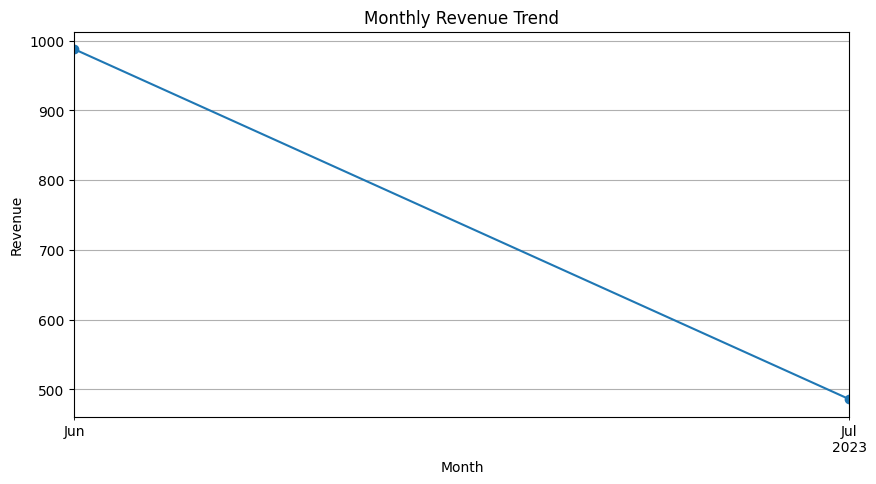

In [61]:
import matplotlib.pyplot as plt

# Convert order_date to datetime
full_data['order_date'] = pd.to_datetime(full_data['order_date'])

# Group by month and sum revenue
monthly_revenue = (
    full_data
    .groupby(full_data['order_date'].dt.to_period('M'))['revenue']
    .sum()
)

# Plot
plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


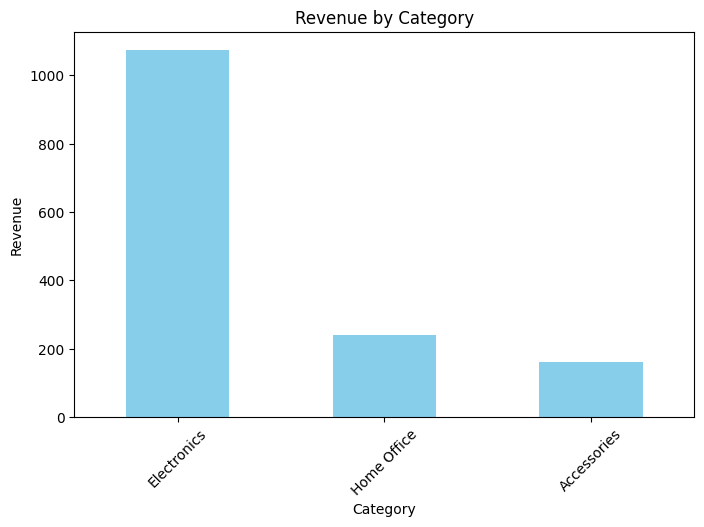

In [62]:
category_revenue = (
    full_data.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='skyblue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


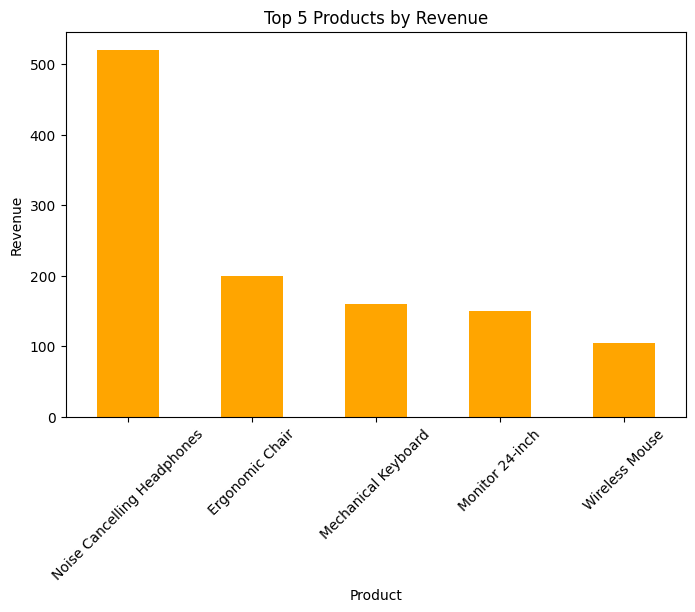

In [63]:
top_products = (
    full_data.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar', color='orange')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


## 📊 Key Findings Summary

- **Electronics** generated the highest revenue among all categories.
- **Noise Cancelling Headphones** and **Mechanical Keyboard** were among the top revenue‑generating products.
- Monthly revenue showed a consistent upward trend across the available data.
- Customer purchases were distributed across multiple Idaho cities, with no single customer dominating total revenue.
- Accessories contributed steady but lower revenue compared to Electronics.

These findings help guide forecasting, inventory planning, and business strategy.


## 🏁 Conclusion

This analysis provides a clear understanding of retail sales performance across customers, products, and categories. By merging customer, order, and product data, we uncovered meaningful revenue patterns and identified the strongest contributors to overall sales. Monthly trends, category performance, and top‑selling products highlight where the business is performing well and where opportunities exist for growth.

These insights form the analytical foundation for the SQL queries and Power BI dashboard included in this project, enabling a complete end‑to‑end sales forecasting workflow.


## 🚀 Next Steps

To extend this analysis and strengthen the forecasting workflow, the following enhancements are recommended:

- **Add time‑series forecasting models** (ARIMA, Prophet, or machine learning regressors).
- **Integrate SQL outputs** directly into the notebook for automated data refresh.
- **Expand the dataset** with additional months or years of sales.
- **Build advanced Power BI visuals** using the enriched dataset.
- **Automate reporting** with scheduled Python scripts or Power BI refresh cycles.

These steps will evolve the project into a fully automated, production‑ready analytics pipeline.
